# Data Analysis

Thomas E. Saunders

## Set up

In [ ]:

library(akldogs)
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'kableExtra'

The following object is masked from 'package:dplyr':

    group_rows


Attaching package: 'scales'

The following object is masked from 'package:purrr':

    discard

The following object is masked from 'package:readr':

    col_factor


Attaching package: 'Hmisc'

The following objects are masked from 'package:dplyr':

    src, summarize

The following objects are masked from 'package:base':

    format.pval, units

corrplot 0.95 loaded


Attaching package: 'plotly'

The following object is masked from 'package:Hmisc':

    subplot

The following object is masked from 'package:ggplot2':

    last_plot

The following object is masked from 'package:stats':

    filter

The following object is masked from 'package:graphics':

    layout

In [ ]:

report_files <- list.files("../data", pattern = "am-reports", full.names = TRUE)

report_names <- report_files |> 
  path_file() |> 
  path_ext_remove() |> 
  str_extract("[^-]+$")

report_data <- report_files |> 
  set_names(report_names) |> 
  map(read_csv)


Rows: 96 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): category
dbl (2): year, count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 48 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): category
dbl (2): year, count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 108 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): category
dbl (2): year, count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 224 Columns: 3
── Column specification ────────────────────────

In [ ]:
registration <- registration  |> 
  clean_breed_names(starts_with("animal_breed")) |> 
  rename(suburb = suburb_name)

rfs <- rename(rfs, suburb = location_suburb_name)


## Auckland Dog Population Overview

In [ ]:
reg_2025 <-
  registration |> 
  filter(sheet_name == "FY25")


As the dog population has increased, rates of registration and desexing have fallen, while rates of menacing dog ownership have increased.

In [ ]:

ownership_trends <-
  report_data$ownership |>
  pivot_wider(
    names_from = category,
    values_from = count
  ) |> 
  arrange(year) |>
  mutate(
    prev_value = lag(dogs),
    change = dogs - prev_value,
    pc_change = change / dogs,
    reg_pc = registered / dogs,
    desex_pc = desexed / dogs,
    men_pc = menacing / dogs
  ) |>
  select(year, dogs, pc_change:men_pc) |> 
  arrange(desc(year)) |> 
  rename(
    "Year" = year,
    "Known Dogs" = dogs,
    "Pop. Change (%)" = pc_change,
    "Registered (%)" = reg_pc,
    "Desexed (%)" = desex_pc,
    "Menacing (%)" = men_pc
  ) |> 
  mutate(
    across(contains("%"),
           ~ scales::percent(., accuracy = 0.1)),
    "Known Dogs" = format(`Known Dogs`, big.mark = ",")
  )

ownership_trends |> 
  kable() |> 
  kable_styling()


    Year Known Dogs   Pop. Change (%)   Registered (%)   Desexed (%)   Menacing (%)
  ------ ------------ ----------------- ---------------- ------------- --------------
    2025 131,123      -3.4%             88.4%            65.0%         5.1%
    2024 135,546      2.8%              83.6%            66.4%         4.7%
    2023 131,795      5.1%              88.2%            68.2%         4.1%
    2022 125,016      5.2%              91.0%            50.7%         4.3%
    2021 118,552      5.1%              94.8%            73.4%         4.1%
    2020 112,530      1.4%              94.4%            NA            4.2%
    2019 110,969      0.9%              96.1%            NA            4.0%
    2018 110,012      -5.0%             93.6%            NA            3.9%
    2017 115,544      0.9%              83.7%            NA            3.6%
    2016 114,519      4.1%              93.2%            NA            2.4%
    2015 109,840      4.3%              91.2%            NA            2.7%
    2014 105,095      NA                95.9%            NA            0.7%


Top 10 primary breeds as at FY2025:

In [ ]:

primary_breed <- reg_2025 |> 
  calc_proportions("animal_breed_description", count_name = "primary_breed")

primary_breed |> 
  rename(
    "Breed" = animal_breed_description,
    "Count" = primary_breed,
    "Proportion" = prop
  ) |> 
  mutate(
    Proportion = scales::percent(Proportion, accuracy = 0.1),
    Count = format(Count, big.mark = ",")
  ) |> 
  head(n = 10) |> 
  kable() |> 
  kable_styling()


  Breed                           Count    Proportion
  ------------------------------- -------- ------------
  Labrador Retriever              14,959   11.4%
  Staffordshire Bull Terrier      8,474    6.5%
  Border Collie                   6,170    4.7%
  Miniature Schnauzer             4,900    3.7%
  Cavalier King Charles Spaniel   4,784    3.6%
  Golden Retriever                4,636    3.5%
  Shih Tzu                        4,216    3.2%
  German Shepherd                 4,196    3.2%
  American Pit Bull Terrier       3,908    3.0%
  Jack Russell Terrier            3,641    2.8%


Dog population secondary breed counts

In [ ]:
secondary_breed <- reg_2025 |> 
  calc_proportions("animal_breed2_description", count_name = "secondary_breed")

head(secondary_breed, n = 10)


# A tibble: 10 × 3
   animal_breed2_description     secondary_breed   prop
   <chr>                                   <int>  <dbl>
 1 <NA>                                    75366 0.575 
 2 Cross                                   19253 0.147 
 3 Miniature Poodle                         3190 0.0243
 4 Standard Poodle                          2885 0.0220
 5 Labrador Retriever                       2861 0.0218
 6 Toy Poodle                               1802 0.0137
 7 Staffordshire Bull Terrier               1789 0.0136
 8 Cavalier King Charles Spaniel            1519 0.0116
 9 Shih Tzu                                 1501 0.0114
10 Border Collie                            1393 0.0106

Primary breeds most commonly classified as ‘menacing’ due to behaviour

In [ ]:
menacing_breed <-
  reg_2025 |>
  filter(classification == "Menacing - observed or reported behaviour of dog") |> 
  count(animal_breed_description, name = "menacing") |>
  left_join(primary_breed |> rename(primary_prop = prop), by = join_by(animal_breed_description)) |>
  filter(primary_breed > 100) |> 
  mutate(menacing_prop = menacing / primary_breed) |> 
  arrange(desc(menacing_prop)) 
  
head(menacing_breed, n = 10)


# A tibble: 10 × 5
   animal_breed_description menacing primary_breed primary_prop menacing_prop
   <chr>                       <int>         <int>        <dbl>         <dbl>
 1 Akita                           8           102     0.000778        0.0784
 2 Siberian Husky                 63          1330     0.0101          0.0474
 3 American Bulldog               66          1707     0.0130          0.0387
 4 Neapolitan Mastiff             11           293     0.00223         0.0375
 5 Mastiff                        57          1526     0.0116          0.0374
 6 Shar Pei                       71          2445     0.0186          0.0290
 7 Dogue de Bordeaux               4           139     0.00106         0.0288
 8 Weimaraner                      4           152     0.00116         0.0263
 9 Bull Terrier                   16           666     0.00508         0.0240
10 Bull Mastiff                   24          1077     0.00821         0.0223

The rate of attacks on people per 1,000 dogs has increased from 6 in FY2016, to 10 in FY2025.

In [ ]:
attack_rate <-
  report_data$service |> 
  filter(category == "attack-people") |>
  select(-category) |> 
  rename(count_attacks = count) |> 
  left_join(
    report_data$ownership |> 
      filter(category == "dogs") |> 
      select(-category) |> 
      rename(count_dogs = count),
    by = join_by(year)) |> 
  mutate(
    attack_rate = round((count_attacks / count_dogs) * 1000, digits = 1),
  )

head(attack_rate, n = 10)


# A tibble: 10 × 4
    year count_attacks count_dogs attack_rate
   <dbl>         <dbl>      <dbl>       <dbl>
 1  2025          1341     131123        10.2
 2  2024          1253     135546         9.2
 3  2023          1098     131795         8.3
 4  2022           848     125016         6.8
 5  2021           756     118552         6.4
 6  2020           685     112530         6.1
 7  2019           716     110969         6.5
 8  2018           745     110012         6.8
 9  2017           816     115544         7.1
10  2016           740     114519         6.5

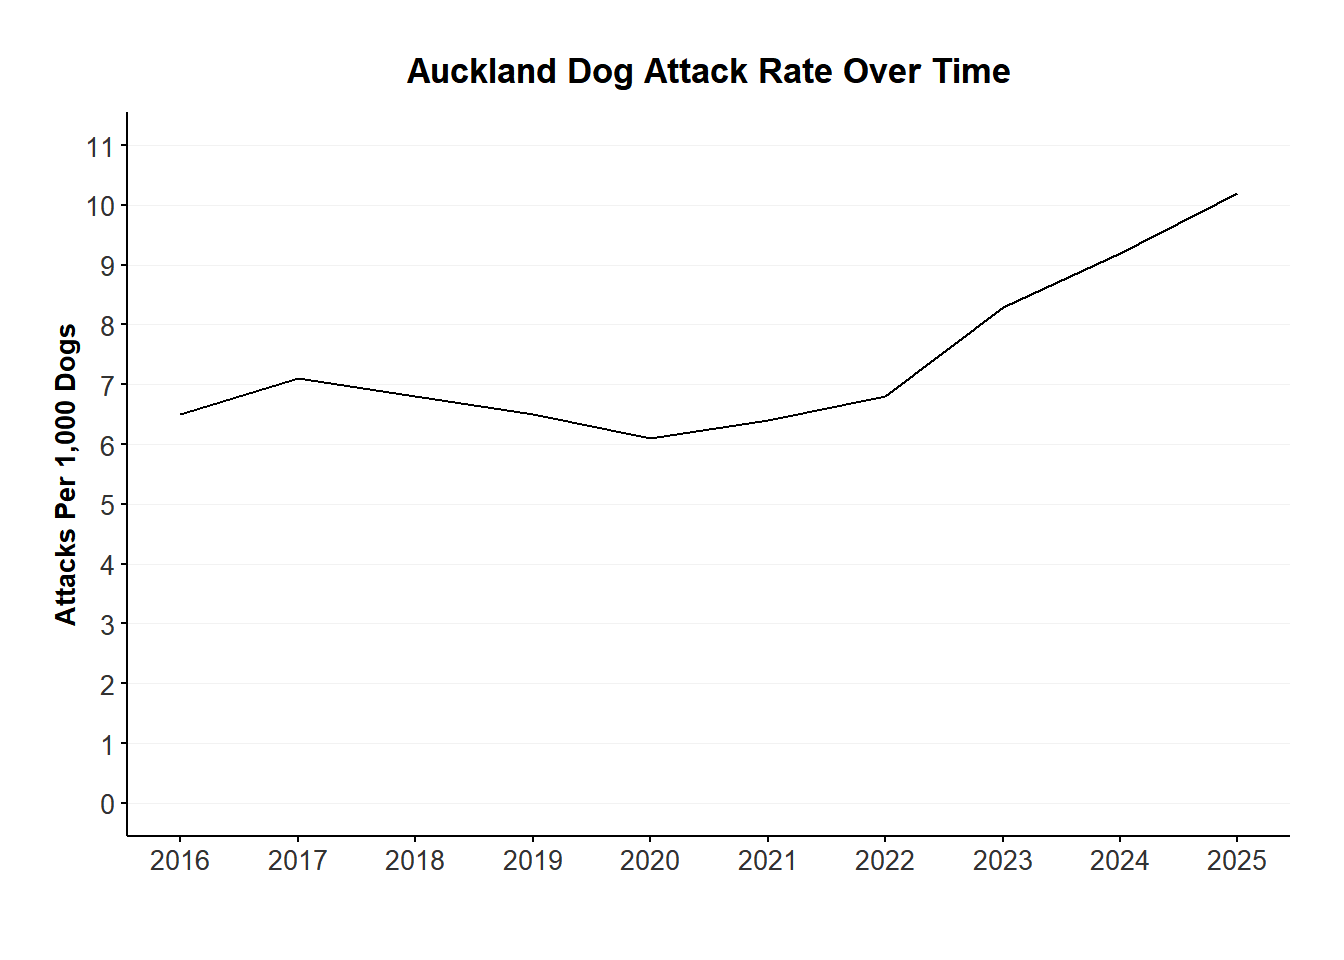

In [ ]:

ggplot(attack_rate |> filter(year > 2015), aes(x = year, y = attack_rate)) +
  geom_line() +
  scale_y_continuous(limits = c(0, 11), breaks = seq(0, 11, by = 1)) +
  scale_x_continuous(breaks = 2016:max(attack_rate$year)) +
  xlab("") +
  ylab("Attacks Per 1,000 Dogs") +
  plot_theme() +
  labs(title = "Auckland Dog Attack Rate Over Time")


Impounds

In [ ]:

impound_rate <-
  report_data$ownership |> 
  filter(category == "dogs") |> 
  rename("dogs" = "count") |> 
  select(-category) |> 
  left_join(report_data$impounds |> filter(category == "impounds"),
            by = join_by(year)) |> 
  rename("impounds" = "count") |> 
  select(-category) |> 
  mutate(
    impound_rate = round((impounds / dogs) * 1000, digits = 1)
  )

impound_rate |> 
  rename(
    "Year" = year,
    "Known Dogs" = dogs,
    "Impounded Dogs" = impounds,
    "Impound Rate" = impound_rate
  ) |> 
  mutate(
    across(c(`Known Dogs`, `Impounded Dogs`), ~ format(.,big.mark = ","))
  ) |> 
  kable() |> 
  kable_styling()


    Year Known Dogs   Impounded Dogs     Impound Rate
  ------ ------------ ---------------- --------------
    2025 131,123      10,214                     77.9
    2024 135,546      8,306                      61.3
    2023 131,795      6,596                      50.0
    2022 125,016      5,012                      40.1
    2021 118,552      5,228                      44.1
    2020 112,530      5,492                      48.8
    2019 110,969      6,833                      61.6
    2018 110,012      7,457                      67.8
    2017 115,544      8,416                      72.8
    2016 114,519      8,614                      75.2
    2015 109,840      9,432                      85.9
    2014 105,095      7,373                      70.2


Top 3 primary breeds for each attack severity rating for impounded dogs in FY2024

In [ ]:
attack_severity <-
  impounds |> 
  filter(impound_date > "2023-07-01" & !is.na(severity)) |> 
  group_by(severity) |> 
  count(primary_breed) |> 
  arrange(desc(severity), desc(n))

attack_severity |> 
  group_by(severity) |>
  slice_max(order_by = n, n = 3) |> 
  arrange(desc(severity))


# A tibble: 19 × 3
# Groups:   severity [6]
   severity primary_breed                      n
   <chr>    <chr>                          <int>
 1 5        Pit Bull Terrier                  17
 2 5        Staffordshire Bull Terrier        12
 3 5        American Bulldog                   8
 4 4        Pit Bull Terrier                  30
 5 4        Staffordshire Bull Terrier        25
 6 4        American Bulldog                  12
 7 4        Shar Pei                          12
 8 3        Pit Bull Terrier                  26
 9 3        Staffordshire Bull Terrier        17
10 3        American Staffordshire Terrier     9
11 2        Pit Bull Terrier                  25
12 2        Staffordshire Bull Terrier        17
13 2        Mastiff                           10
14 1        Staffordshire Bull Terrier        10
15 1        American Bulldog                   4
16 1        Pit Bull Terrier                   4
17 0        Pit Bull Terrier                  34
18 0        Staffordshire

The overall rate of euthanising impounded dogs was dropping between 2014-2019. But after COVID, the rate has increased to be higher than ever before.

(`geom_bar()`).

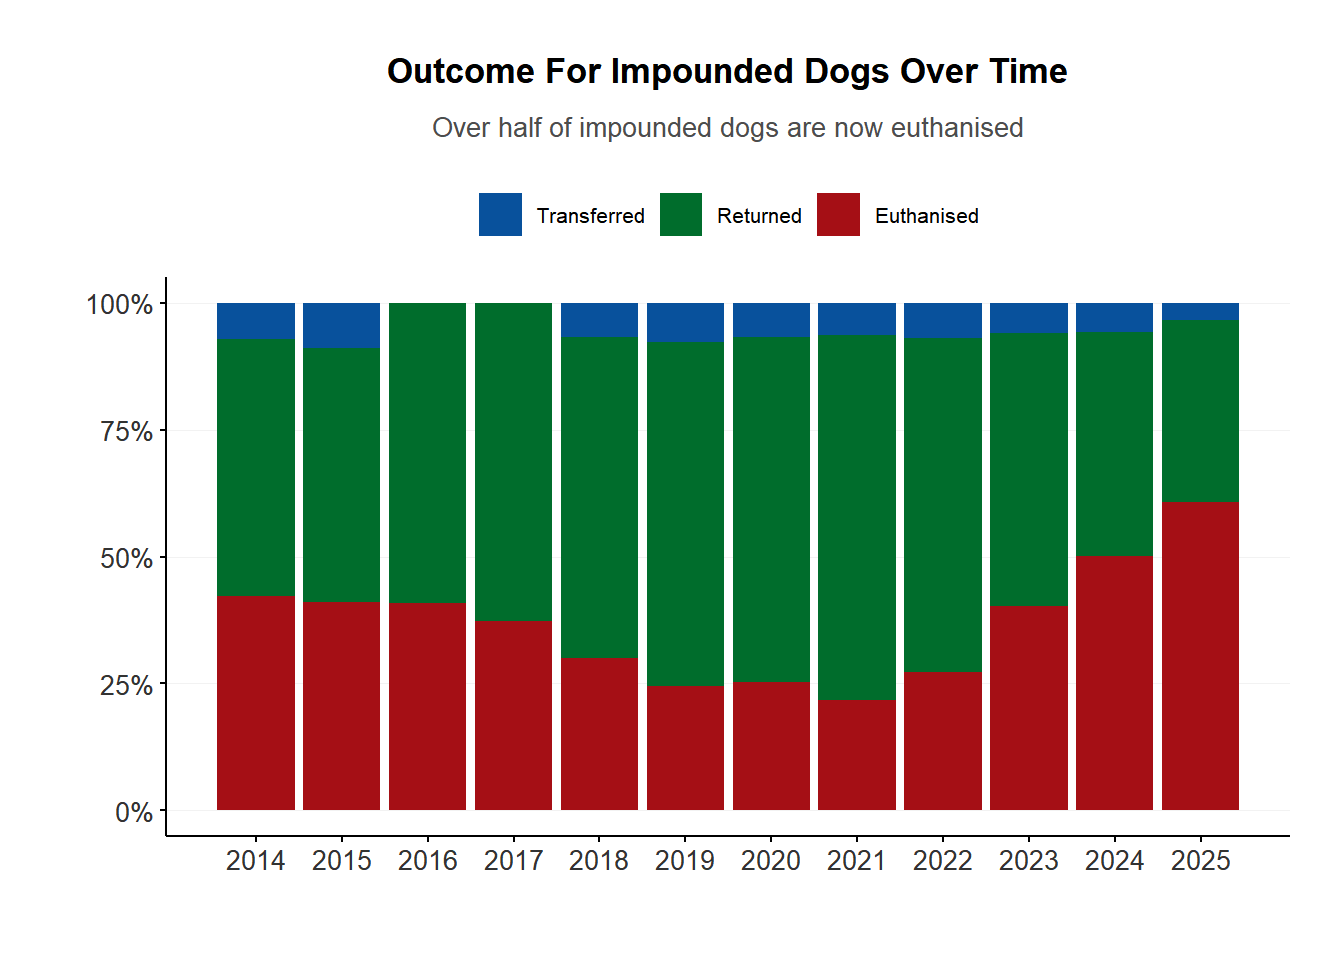

In [ ]:

impound_result <-
  report_data$impounds |> 
  filter(category != "impounds")

impound_result$category <- factor(impound_result$category, 
                                 levels = c("transferred", "returned", "euthanised"))

ggplot(impound_result, aes(x = year, y = count, fill = category)) +
  geom_bar(position = "fill", stat = "identity") +
  scale_fill_manual(values = c("#08519c", "#006d2c", "#a50f15"),
                    labels = tools::toTitleCase) +
  scale_y_continuous(labels = scales::label_percent()) +
  scale_x_continuous(breaks = unique(impound_result$year)) +
  xlab("") +
  ylab("") +
  plot_theme() +
  labs(title = "Outcome For Impounded Dogs Over Time",
       subtitle = "Over half of impounded dogs are now euthanised")


Impound outcome by primary breed (population and impound data are both FY2024)

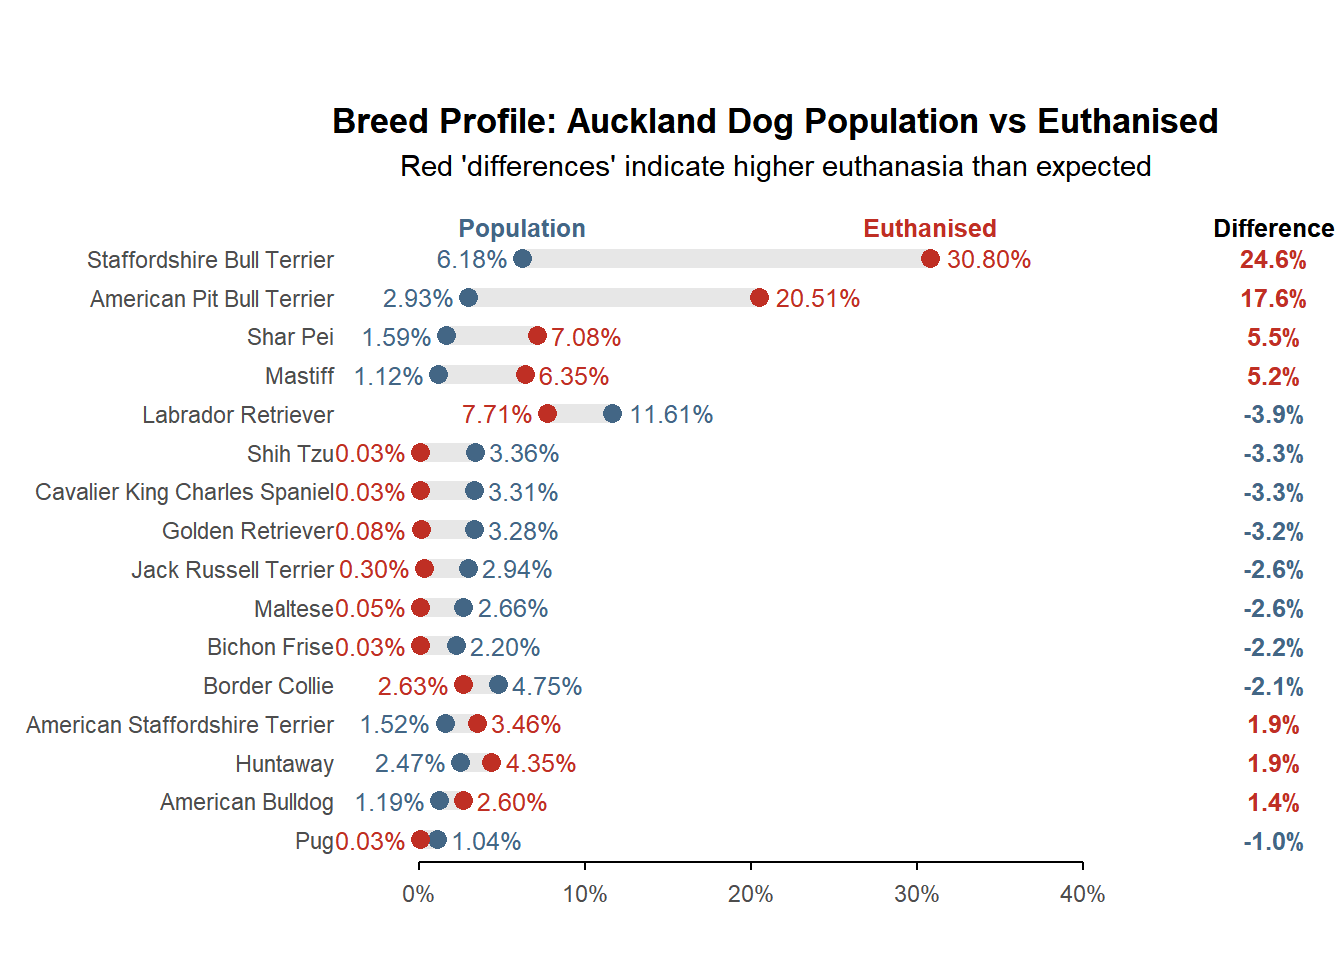

In [ ]:

breed_data <- registration |>
  filter(sheet_name == "FY24") |>
  count(primary_breed = animal_breed_description, name = "n_pop") |>
  mutate(prop_pop = n_pop / sum(n_pop)) |>
  inner_join(
    impounds |>
      filter(impound_date > "2023-07-01", status %in% c("Euthanised", "For Euthanasia")) |>
      mutate(primary_breed = str_replace(primary_breed, ".*Pit Bull Terrier.*", "American Pit Bull Terrier")) |>
      count(primary_breed, name = "n_euth") |>
      mutate(prop_euth = n_euth / sum(n_euth)),
    by = "primary_breed"
  ) |>
  mutate(
    diff = prop_euth - prop_pop,
    max_val = pmax(prop_euth, prop_pop) 
  ) |>
  filter(abs(diff) > 0.01) |>
  arrange(abs(diff)) |>
  mutate(primary_breed = fct_inorder(primary_breed))

colours <- c("prop_euth" = "#BF2F24", "prop_pop"  = "#436685")
n_breeds <- nrow(breed_data)

p1 <- breed_data |>
  pivot_longer(cols = starts_with("prop"), names_to = "type", values_to = "val") |>
  ggplot(aes(val, primary_breed)) +
  geom_line(aes(group = primary_breed), color = "#E7E7E7", linewidth = 3.5) +
  geom_point(aes(color = type), size = 3) +
  geom_text(aes(label = percent(val, 0.01), color = type, 
                hjust = if_else(val == max_val, -0.2, 1.2)), size = 3.25) +
  geom_text(data = \(.x) filter(.x, primary_breed == last(primary_breed)),
            aes(label = if_else(type == "prop_pop", "Population", "Euthanised"), color = type),
            nudge_y = 0.8, fontface = "bold", size = 3.25) +
  scale_x_continuous(
  breaks = seq(0, 0.4, by = 0.10),
  labels = \(x) if_else(round(x, 2) %in% round(seq(0, 0.4, 0.1), 2), 
                        percent(x, accuracy = 1), 
                        ""),
  guide = guide_axis(cap = "both")
  ) +
  scale_color_manual(values = colours) +
  coord_cartesian(xlim = c(-0.02, 0.45), ylim = c(1, n_breeds + 1), clip = "off") +
  labs(title = "Breed Profile: Auckland Dog Population vs Euthanised",
       subtitle = "Red 'differences' indicate higher euthanasia than expected", x = NULL, y = NULL) +
  theme_minimal() +
  theme(
    legend.position = "none", 
    panel.grid = element_blank(), 
    plot.title = element_text(face = "bold", hjust = 0.5), 
    plot.subtitle = element_text(hjust = 0.5),
    axis.line.x = element_line(color = "black", linewidth = 0.5),
    axis.ticks.x = element_line(color = "black", linewidth = 0.5),
    axis.ticks.length.x = unit(3, "pt")
    )

p2 <- ggplot(breed_data, aes(x = 0, y = primary_breed)) +
  geom_text(aes(label = percent(diff, 0.1), color = if_else(diff > 0, "prop_euth", "prop_pop")),
            fontface = "bold", size = 3.25) +
  annotate("text", x = 0, y = n_breeds + 0.8, label = "Difference", fontface = "bold", size = 3.25) +
  scale_color_manual(values = colours) +
  coord_cartesian(ylim = c(1, n_breeds + 1), clip = "off") +
  theme_void() +
  theme(legend.position = "none")

p1 + p2 + plot_layout(widths = c(10, 1)) & 
  theme(plot.margin = margin(20, 5, 10, 5))


Reasons for euthanasia

In [ ]:
euthanised_reason <-
  impounds |>
  filter(impound_date > "2023-07-01" & !is.na(euthanasia_reason)) |>
  mutate(
    euthanasia_reason = case_when(
      str_detect(euthanasia_reason, "Health|Parvo") ~ "Health or Parvo Virus",
      str_detect(euthanasia_reason, "Dog vs Dog|Dog vs Domestic|Dog vs Stock|Dog vs Poultry") ~ "S.57 Dog vs Animal",
      .default = euthanasia_reason
    )
  ) |> 
  group_by(euthanasia_reason) |> 
  count(name = "count") |>
  ungroup() |> 
  mutate(
    proportion = count / sum(count)
  ) |> 
  arrange(desc(proportion))

euthanised_reason


# A tibble: 13 × 3
   euthanasia_reason                 count proportion
   <chr>                             <int>      <dbl>
 1 Failed Temperament Test            1963   0.501   
 2 Shelter Full                        948   0.242   
 3 Health or Parvo Virus               518   0.132   
 4 S.57 Dog vs Animal                  120   0.0306  
 5 S.57 Dog vs Person                  106   0.0271  
 6 No Longer Suitable For Adoption      86   0.0219  
 7 S.57A Aggressive Behaviour           71   0.0181  
 8 Dependant Pup                        37   0.00944 
 9 Relinquish - Aggressive Behaviour    31   0.00791 
10 Destruction Order - S.64             19   0.00485 
11 Menacing Dog - S.33A Deed            13   0.00332 
12 Dangerous Dog - S.31                  3   0.000766
13 Menacing Dog - S.33C Breed            3   0.000766

Total infringements skyrocket in 2025

In [ ]:
report_data$enforcement |> 
  filter(category == "infringements-total")


# A tibble: 12 × 3
    year category            count
   <dbl> <chr>               <dbl>
 1  2025 infringements-total 17430
 2  2024 infringements-total  6387
 3  2023 infringements-total  4748
 4  2022 infringements-total  3271
 5  2021 infringements-total  5126
 6  2020 infringements-total  3480
 7  2019 infringements-total  5172
 8  2018 infringements-total  5817
 9  2017 infringements-total  5098
10  2016 infringements-total  3835
11  2015 infringements-total  4521
12  2014 infringements-total  5638

The bulk of infringements are for failing to register a dog

In [ ]:
report_data$enforcement |> 
  filter(category == "failure-register")


# A tibble: 12 × 3
    year category         count
   <dbl> <chr>            <dbl>
 1  2025 failure-register 10149
 2  2024 failure-register  2305
 3  2023 failure-register  1490
 4  2022 failure-register   763
 5  2021 failure-register  1903
 6  2020 failure-register  1138
 7  2019 failure-register  2028
 8  2018 failure-register  2534
 9  2017 failure-register  2109
10  2016 failure-register  1496
11  2015 failure-register  2200
12  2014 failure-register  3203

But prosecutions remain at low levels

In [ ]:
report_data$enforcement |> 
  filter(category == "prosecutions-appeals")


# A tibble: 12 × 3
    year category             count
   <dbl> <chr>                <dbl>
 1  2025 prosecutions-appeals   141
 2  2024 prosecutions-appeals   117
 3  2023 prosecutions-appeals   121
 4  2022 prosecutions-appeals   117
 5  2021 prosecutions-appeals   134
 6  2020 prosecutions-appeals   161
 7  2019 prosecutions-appeals   220
 8  2018 prosecutions-appeals   237
 9  2017 prosecutions-appeals   217
10  2016 prosecutions-appeals   197
11  2015 prosecutions-appeals   137
12  2014 prosecutions-appeals   210

## Auckland Dog Population By Region

Known dogs

In [ ]:

regions_dogs <- 
  registration |>
  filter(sheet_name == "FY25") |> 
  left_join(locality, by = join_by(suburb)) |>
  select(suburb, local_board, region) |> 
  group_by(suburb) |> 
  add_count(suburb, name = "known_suburb") |> 
  group_by(local_board) |> 
  add_count(local_board, name = "known_board") |> 
  group_by(region) |> 
  add_count(region, name = "known_region") |>
  unique() |> 
  arrange(desc(known_suburb)) |> 
  ungroup()

regions_dogs |> 
  select(region, known_region) |> 
  distinct() |> 
  arrange(desc(known_region)) |> 
  rename(
    "Region" = "region",
    "Dogs" = "known_region"
  ) |> 
  mutate(
    Dogs = format(Dogs, big.mark = ",")
  ) |> 
  kable() |> 
  kable_styling()


  Region    Dogs
  --------- --------
  north     43,051
  south     33,754
  central   25,368
  west      20,046
  east      8,904


Dog population trends in each Local Board

In [ ]:

dogs_board <-
  registration |> 
  select(sheet_name, suburb) |> 
  left_join(locality, by = join_by(suburb)) |> 
  group_by(sheet_name, local_board) |> 
  count() |> 
  pivot_wider(names_from = sheet_name, values_from = n) |> 
  mutate(
    change = (FY25 - FY21) / FY21
  ) |> 
  filter(FY25 > 100) |> 
  arrange(desc(change)) |> 
  ungroup()

dogs_board |> 
  mutate(
    across(contains("FY"), comma),
    change = scales::percent(change, accuracy = 0.1)
  ) |> 
  rename(
    "2021" = "FY21",
    "2022" = "FY22",
    "2023" = "FY23",
    "2024" = "FY24",
    "2025" = "FY25",
    "Change" = "change",
    "Local Board" = "local_board"
  ) |> 
  kable() |> 
  kable_styling()


  Local Board                            2021     2022     2023     2024     2025     Change
  -------------------------------------- -------- -------- -------- -------- -------- --------
  Māngere-Ōtāhuhu Local Board Area       3,407    3,677    4,173    4,670    4,809    41.2%
  Ōtara-Papatoetoe Local Board Area      3,912    4,267    4,668    5,107    5,192    32.7%
  Maungakiekie-Tāmaki Local Board Area   4,540    4,882    5,226    5,514    5,484    20.8%
  Aotea/Great Barrier Local Board Area   295      301      325      341      349      18.3%
  Manurewa Local Board Area              5,043    5,306    5,589    5,923    5,808    15.2%
  Henderson-Massey Local Board Area      9,140    9,514    10,067   10,440   10,288   12.6%
  Upper Harbour Local Board Area         4,880    5,307    5,607    5,696    5,464    12.0%
  Puketāpapa Local Board Area            1,954    2,080    2,227    2,282    2,180    11.6%
  Whau Local Board Area                  3,337    3,493    3,690    3,817    3,694    10.7%
  Hibiscus and Bays Local Board Area     11,369   12,035   12,621   12,994   12,529   10.2%
  Kaipātiki Local Board Area             5,753    6,088    6,458    6,534    6,275    9.1%
  Albert-Eden Local Board Area           5,726    6,128    6,427    6,498    6,233    8.9%
  Howick Local Board Area                8,228    8,672    9,145    9,275    8,904    8.2%
  Waitematā Local Board Area             4,014    4,295    4,462    4,554    4,310    7.4%
  Papakura Local Board Area              5,565    5,859    6,091    6,281    5,967    7.2%
  Devonport-Takapuna Local Board Area    4,290    4,423    4,720    4,799    4,592    7.0%
  Franklin Local Board Area              11,218   11,879   12,426   12,560   11,978   6.8%
  Waitākere Ranges Local Board Area      5,729    5,961    6,211    6,302    6,064    5.8%
  Ōrākei Local Board Area                6,810    7,096    7,403    7,516    7,161    5.2%
  Rodney Local Board Area                12,152   12,555   12,976   13,245   12,635   4.0%
  Waiheke Local Board Area               1,180    1,200    1,271    1,272    1,207    2.3%


In [ ]:
median(dogs_board$change, na.rm = TRUE)


[1] 0.09073527

While the median increase across Auckland local boards was 9%, the Interquartile Range (IQR) analysis below identifies Māngere-Ōtāhuhu and Ōtara-Papatoetoe Local Boards as statistical outliers for their significantly higher growth, distinct from the regional trend.

In [ ]:
# Calculate upper fence
stats <- dogs_board |>
  summarise(
    q1 = quantile(change, 0.25),
    q3 = quantile(change, 0.75),
    iqr = q3 - q1,
    upper_fence = q3 + (1.5 * iqr)
  )

# Flag high outliers
dogs_board_outliers <- dogs_board |>
  mutate(
    is_high_outlier = change > stats$upper_fence,
  ) |>
  filter(is_high_outlier)

dogs_board_outliers


# A tibble: 2 × 8
  local_board                FY21  FY22  FY23  FY24  FY25 change is_high_outlier
  <chr>                     <int> <int> <int> <int> <int>  <dbl> <lgl>          
1 Māngere-Ōtāhuhu Local Bo…  3407  3677  4173  4670  4809  0.412 TRUE           
2 Ōtara-Papatoetoe Local B…  3912  4267  4668  5107  5192  0.327 TRUE           

Registration data

In [ ]:
regions_2025 <-
  registration |> 
  filter(sheet_name == "FY25") |> 
  mutate(
    current_reg = case_when(registration_latest_year < 2024 ~ FALSE, .default = TRUE),
    owner_reg = case_when(owner_registration_class == "RDOL" ~ TRUE),
    classification = case_when(classification == "Unknown" ~ FALSE,
                               str_detect(classification, "Menacing|Dangerous") ~ TRUE)
  ) |> 
  left_join(regions_dogs, by = join_by(suburb)) |> 
  select(current_reg, owner_reg, animal_breed_description, animal_desexed, classification, suburb, local_board:known_region) 
  
regions_reg <- 
  regions_2025 |>
  pivot_longer(
    cols = c(current_reg, owner_reg, animal_desexed, classification),
    names_to = "metric",
    values_to = "is_true"
  ) |>
  group_by(suburb, local_board, region, metric) |>
  summarise(
    count = sum(is_true, na.rm = TRUE),
    known_suburb = first(known_suburb),
    known_board = first(known_board),
    known_region = first(known_region),
    .groups = "drop"
  ) |>
  group_by(metric) |>
  mutate(
    p_suburb = count / known_suburb
  ) |>
  group_by(local_board, metric) |>
  mutate(p_board = sum(count) / first(known_board)) |>
  group_by(region, metric) |>
  mutate(p_region = sum(count) / first(known_region)) |>
  ungroup()

write_csv(regions_reg, "../outputs/regions_reg.csv")


Compare Local Boards

In [ ]:
plot_data <- regions_reg |>
  select(local_board, metric, p_board) |>
  distinct() |> 
  mutate(
    metric = metric |> str_replace_all("_", " ") |> str_to_title(),
    local_board = local_board |> str_replace_all("_", " ") |> str_to_title()
  )

plots_list <- plot_data |> group_split(metric)

p <- plots_list |> 
  reduce(\(p_obj, data_slice) {
    p_obj |> 
      add_bars(
        data = data_slice,
        x = ~p_board,
        y = ~fct_reorder(local_board, p_board),
        name = unique(data_slice$metric),
        marker = list(color = region_colours[which(plots_list == list(data_slice))]),
        visible = (identical(data_slice, plots_list[[1]])),
        orientation = 'h',
        showlegend = FALSE,
        hovertemplate = "Board: %{y}<br>Value: %{x:.1%}<extra></extra>"
      )
  }, .init = plot_ly(height = 800))

buttons <- plots_list |> 
  imap(\(data_slice, idx) {
    vis_vector <- rep(FALSE, length(plots_list))
    vis_vector[idx] <- TRUE
    list(
      method = "restyle",
      args = list("visible", as.list(vis_vector)),
      label = unique(data_slice$metric)
    )
  })

interactive_plot <- p |> 
  layout(
    title = list(
      text = "Animal Registration Metrics by Local Board (FY25)",
      x = 0.05,    
      y = 0.98,       
      xanchor = 'left',
      yanchor = 'top',
      font = list(size = 20)
    ),
    margin = list(l = 180, t = 100, r = 30, b = 50),
    xaxis = list(title = "", tickformat = ".0%"),
    yaxis = list(title = ""),
    updatemenus = list(
      list(
        buttons = buttons,
        direction = "down",
        showactive = TRUE,
        x = 0.10, 
        y = 1.05, 
        xanchor = 'left',
        yanchor = 'top',
        bgcolor = "#f8f9fa"
      )
    )
  )

htmlwidgets::saveWidget(interactive_plot, "../outputs/reg_metrics.html", selfcontained = TRUE)


The below Spearman rank correlation analysis shows that Local Boards with high current registrations tend to have high rates of desexing and low rates of classified animals, while those with high rates of classifications tend to have lower rates of desexing.

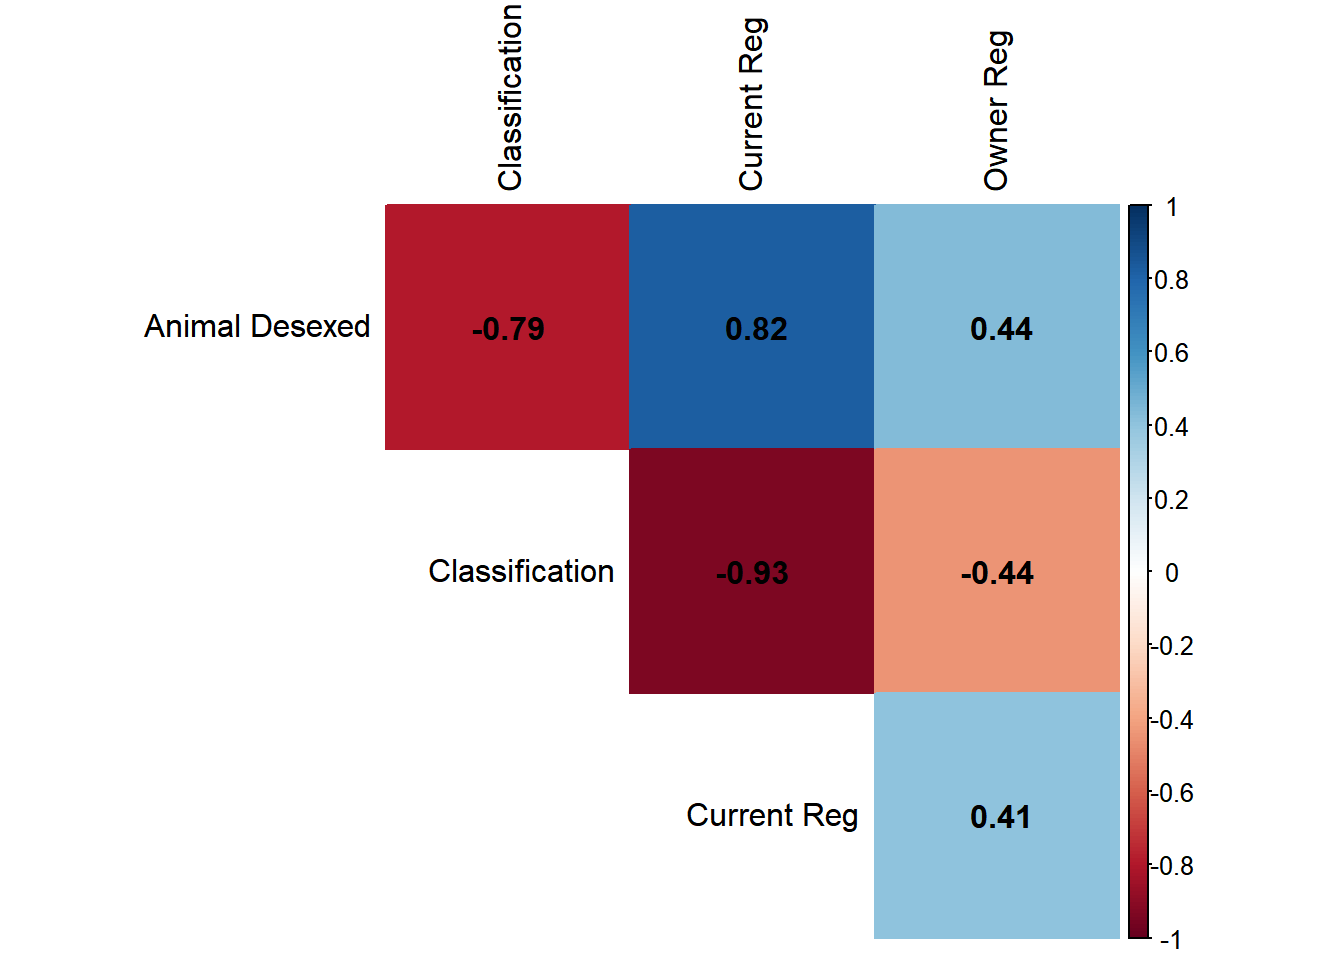

In [ ]:

corr <- plot_data |>
  pivot_wider(names_from = metric, values_from = p_board) |> 
  select(-local_board) |> 
  as.matrix()

cor_results <- rcorr(corr, type = "spearman")

corrplot(cor_results$r, 
         method = "color", 
         type = "upper", 
         addCoef.col = "black", 
         tl.col = "black", 
         diag = FALSE,
         sig.level = 0.05, 
         insig = "blank")


Attacks per 1,000 known dogs in each Local Board

In [ ]:
regions_attacks <- rfs |>
  filter(
    rfs_date >= "2024-07-01",
    str_to_lower(rfs_type) %in% c("dog attack on people", "dog attack on child")
  ) |>
  count(suburb, name = "attacks_suburb") |>
  inner_join(regions_dogs, by = "suburb") |>
  group_by(local_board) |>
  mutate(attacks_board = sum(attacks_suburb)) |>
  group_by(region) |>
  mutate(attacks_region = sum(attacks_suburb)) |>
  ungroup() |>
  mutate(
    rate_suburb = (attacks_suburb / known_suburb) * 1000,
    rate_board  = (attacks_board / known_board) * 1000,
    rate_region = (attacks_region / known_region) * 1000
  ) |>
  select(suburb, local_board, region, starts_with("attacks"), starts_with("known"), starts_with("rate"))

write_csv(regions_attacks, "../outputs/regions_attacks.csv")


Primary breed profile for each region

In [ ]:
regions_breed <-
  registration |> 
  filter(sheet_name == "FY25") |> 
  left_join(locality, by = join_by(suburb)) |> 
  group_by(region) |> 
  count(animal_breed_description, name = "count") |> 
  arrange(desc(count), .by_group = TRUE) |> 
  left_join(regions_dogs |> select(region, known_region) |> unique(), by = join_by(region)) |>
  mutate(
    prop_breed = format(count / known_region, scientific = FALSE)
  )


Compare regional breed profiles statistically

In [ ]:
breeds_region <- regions_breed |>
  perform_chisq(
    group_var = "region", 
    cat_var = "animal_breed_description", 
    count_var = "count"
  )


ℹ Please use `all_of(var)` (or `any_of(var)`) instead of `.data[[var]]`

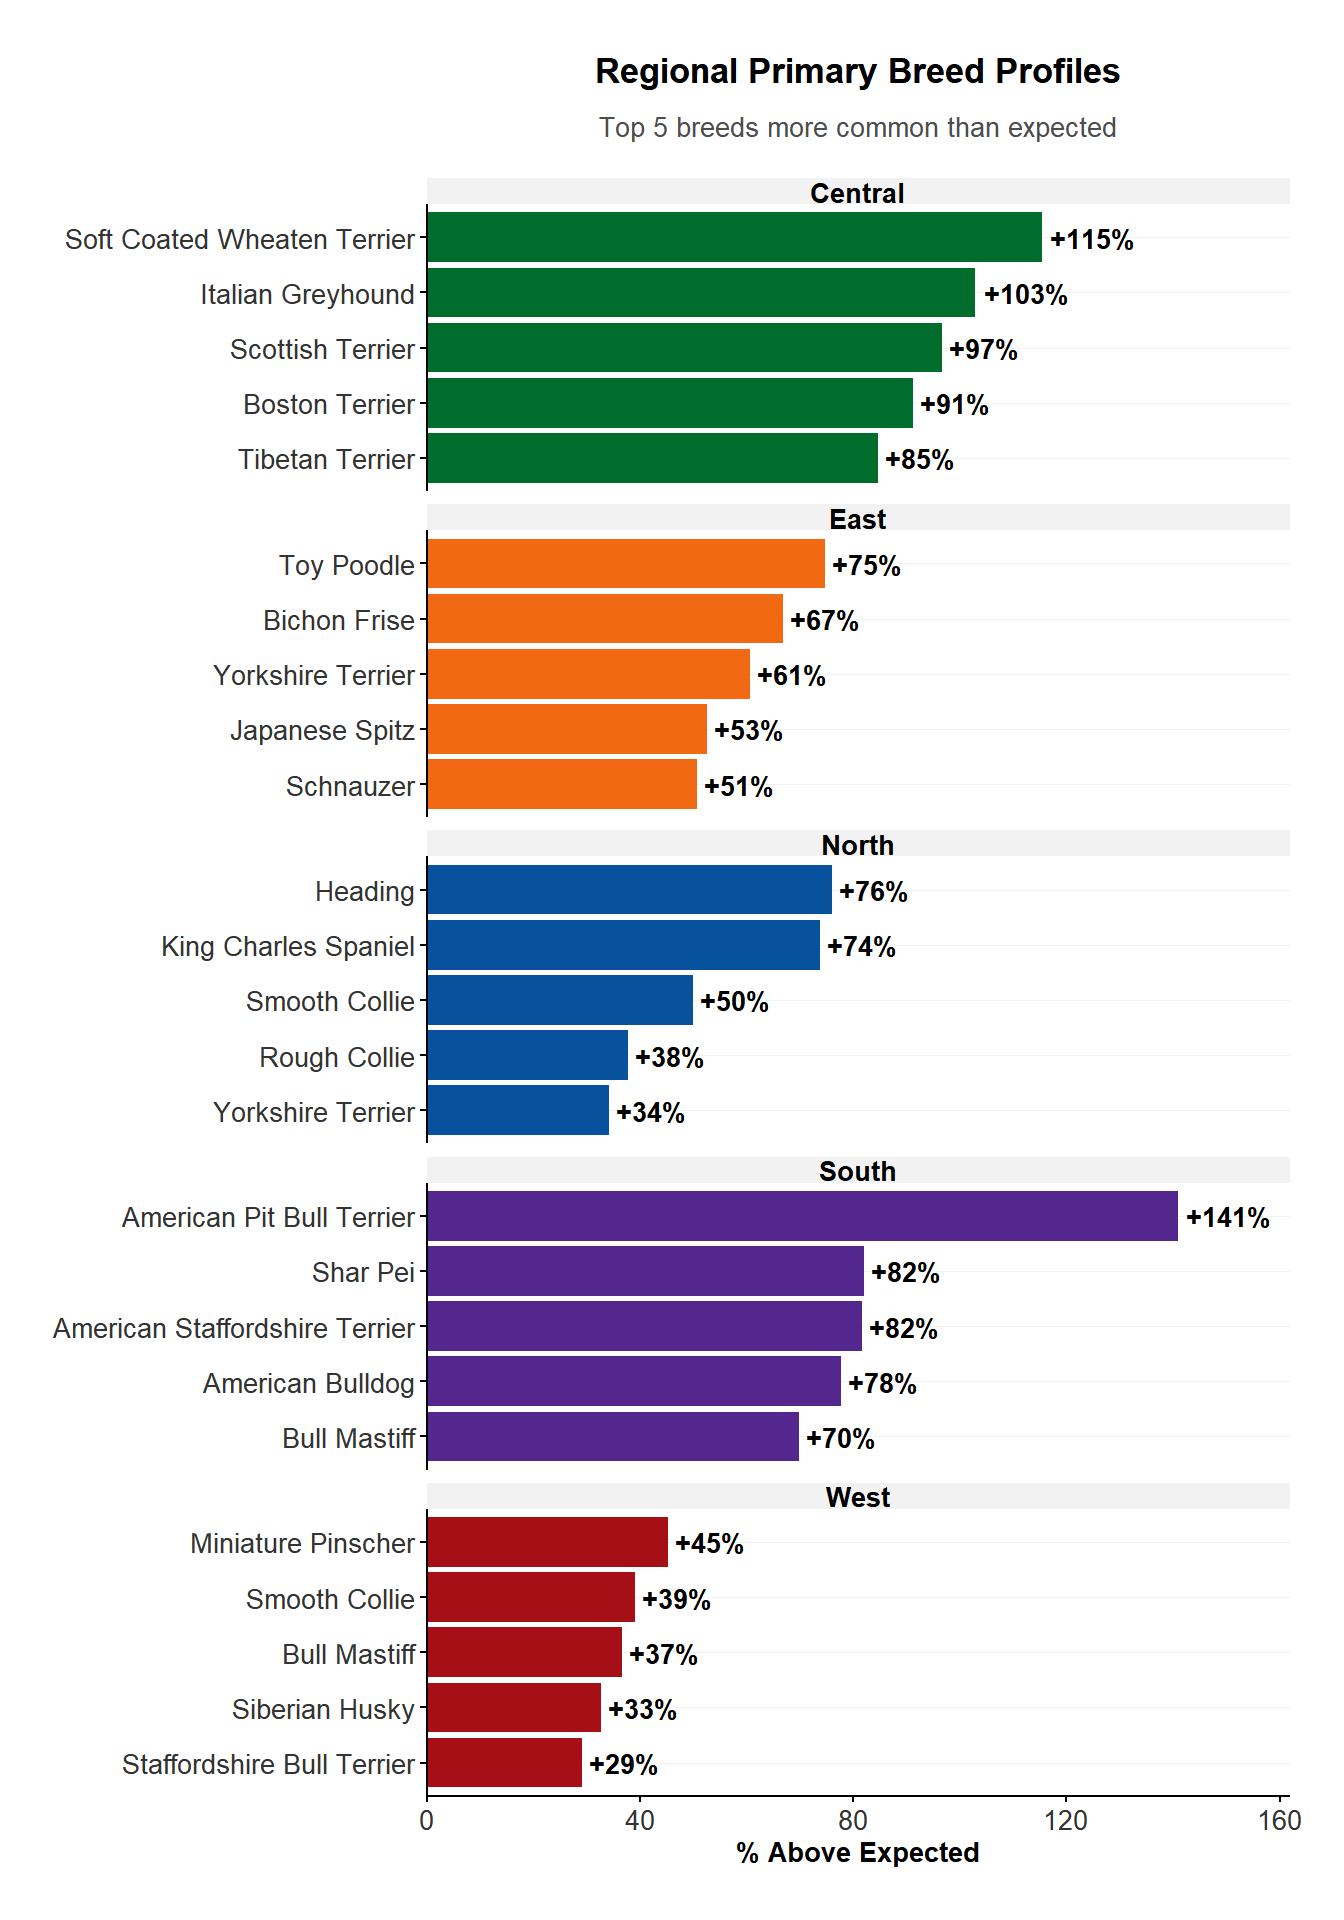

In [ ]:

breeds_region |> 
  group_by(group) |> 
  slice_max(percent_diff, n = 5) |> 
  ungroup() |> 
  ggplot(aes(x = reorder_within(category, percent_diff, group), 
             y = percent_diff, 
             fill = group)) +
  geom_col() +
  scale_fill_manual(values = region_colours) +
  geom_text(aes(label = paste0("+", round(percent_diff), "%")), 
            hjust = -0.1, size = 3.5, fontface = "bold") +
  scale_x_reordered() +
  coord_flip() +
  facet_wrap(~group, scales = "free_y", ncol = 1,
             labeller = function(labels) {
      lapply(labels, tools::toTitleCase)
    }) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  plot_theme() +
  theme(legend.position = "none") +
  labs(
    title = "Regional Primary Breed Profiles",
    subtitle = "Top 5 breeds more common than expected",
    x = NULL, y = "% Above Expected"
  )


Impounds per 1,000 dogs (FY2024 data)

In [ ]:
regions_impounds <- impounds |>
  filter(impound_date > "2023-07-01") |>
  count(suburb, name = "impounds_suburb") |>
  inner_join(locality, by = "suburb") |> 
  left_join(regions_dogs |> select(local_board, known_board, known_region), by = "local_board") |>
  unique() |> 
  group_by(local_board) |>
  mutate(impounds_board = sum(impounds_suburb)) |>
  group_by(region) |>
  mutate(impounds_region = sum(impounds_suburb)) |>
  ungroup() |>
  mutate(
    rate_board  = (impounds_board / known_board) * 1000,
    rate_region = (impounds_region / known_region) * 1000
  ) |>
  select(suburb, local_board, region, starts_with("impounds"), starts_with("known"), starts_with("rate"))


Warning in left_join(inner_join(count(filter(impounds, impound_date > "2023-07-01"), : Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 23 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.

Impound rate for attacks/rushing (FY2024 data)

In [ ]:
attack_codes <- c("Relq - Sec 57", "Sec 57")
rush_codes   <- c("Sec 57A")

regions_impounds_attacks <- impounds |>
  filter(
    impound_date > "2023-07-01",
    impound_reason %in% c(attack_codes, rush_codes)
  ) |>
  count(suburb, name = "impounds_attack_suburb") |>
  inner_join(locality, by = "suburb") |>
  left_join(regions_dogs |> select(local_board, known_board, known_region), by = "local_board") |> 
  unique() |> 
  group_by(local_board) |>
  mutate(impounds_attack_board = sum(impounds_attack_suburb, na.rm = TRUE)) |>
  group_by(region) |>
  mutate(impounds_attack_region = sum(impounds_attack_suburb, na.rm = TRUE)) |>
  ungroup() |>
  mutate(
    across(starts_with("known"), ~replace_na(.x, 0)),
    rate_attack_board  = (impounds_attack_board / known_board) * 1000,
    rate_attack_region = (impounds_attack_region / known_region) * 1000
  ) |>
  mutate(across(starts_with("rate"), ~if_else(is.infinite(.x), NA_real_, .x))) |>
  select(suburb, local_board, region, starts_with("impounds"), starts_with("known"), starts_with("rate_attack"))


Warning in left_join(inner_join(count(filter(impounds, impound_date > "2023-07-01", : Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 29 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.

Outcome of impound by area

ℹ In argument: `status = case_match(...)`.
Caused by warning:
! `case_match()` was deprecated in dplyr 1.2.0.
ℹ Please use `recode_values()` instead.

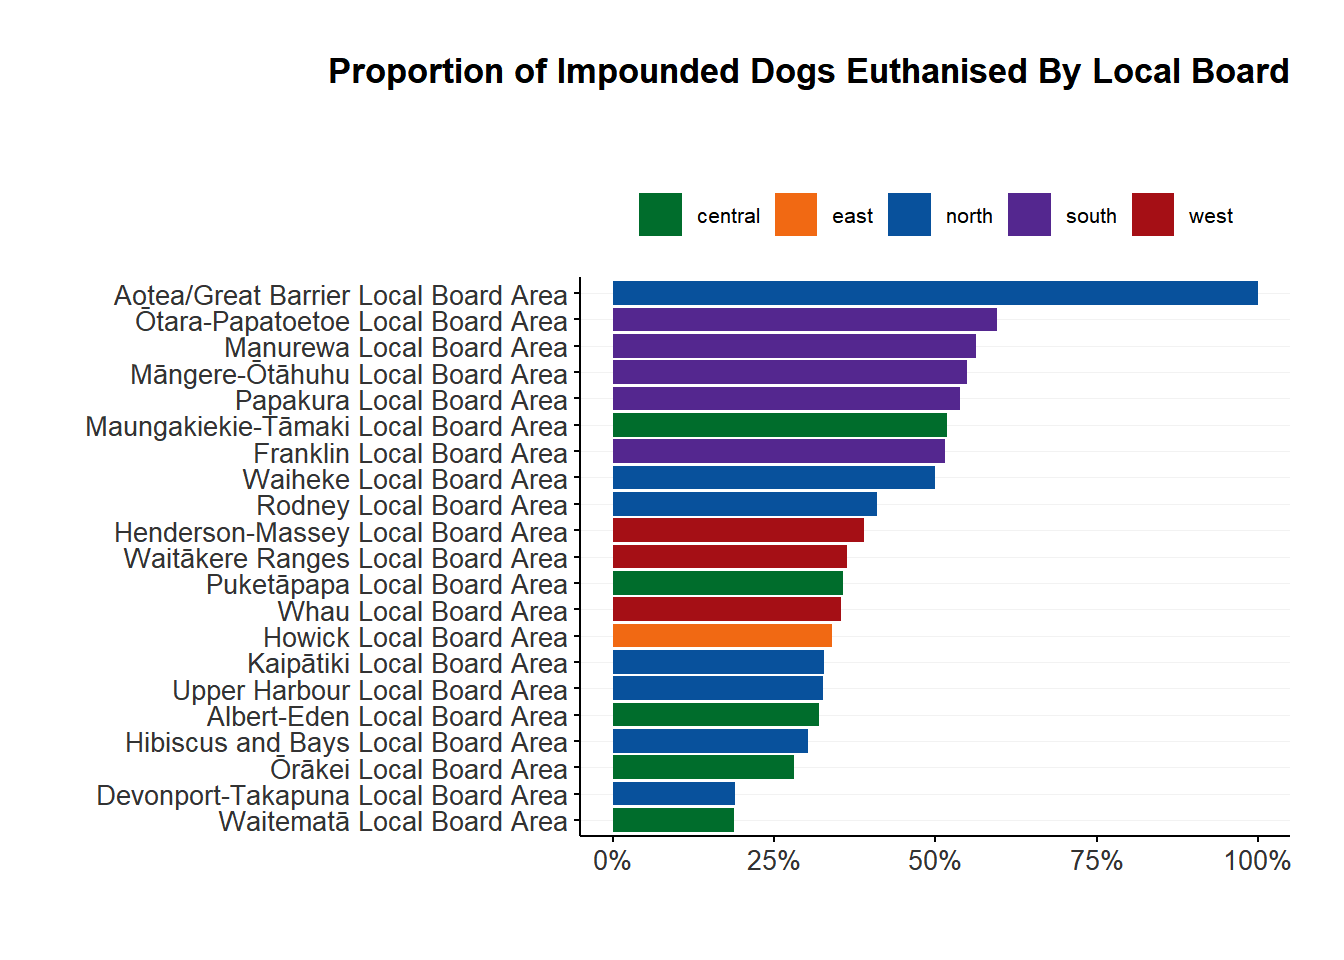

In [ ]:

regions_impounds_outcome <- impounds |>
  filter(impound_date > "2023-07-01") |>
  mutate(status = case_match(status, 
      "For Euthanasia" ~ "Euthanised",
      c("Adoption Pending", "Fostered", "Hold - Adoption") ~ "Adopted",
      c("Trfd to Breed Rescue", "Trfd to Other TA", "Trfd to Rescue Group", "Trfd to SPCA") ~ "Rescued",
      c("Dead on Arrival", "Died in Shelter", "Escaped", "Hold - General", 
        "Hold - Legal Reason", "Hold - Temp Test", "Processing", "Stolen") ~ "Other",
      .default = status
    )
  ) |>
  left_join(regions_dogs, by = "suburb") |>
  count(region, local_board, status, name = "count") |>
  group_by(local_board) |>
  mutate(
    board_total = sum(count),
    proportion = count / board_total
  ) |> 
  ungroup()


Impounds by breed

In [ ]:

impounds_breed <- impounds |>
  filter(impound_date > "2023-07-01") |>
  count(primary_breed, name = "impound_count") |>
  inner_join(
    primary_breed |> select(-prop),
    by = join_by(primary_breed == animal_breed_description)
  ) |>
  mutate(impound_rate = round((impound_count / primary_breed.y) * 1000, digits = 1)) |>
  filter(primary_breed.y > 99) |>
  arrange(desc(impound_rate)) |> 
  head(n = 10)

impounds_breed |> 
  rename("Breed" = primary_breed,
         "Impounds" = impound_count,
         "Population" = primary_breed.y,
         "Impound Rate" = impound_rate) |> 
  mutate(
    across(c(`Impounds`, `Population`), ~ format(.,big.mark = ","))
  ) |> 
  kable() |> 
  kable_styling()


  Breed                            Impounds   Population     Impound Rate
  -------------------------------- ---------- ------------ --------------
  Mastiff                          486        1,526                 318.5
  Staffordshire Bull Terrier       1,972      8,474                 232.7
  Shar Pei                         494        2,445                 202.0
  American Bulldog                 285        1,707                 167.0
  American Staffordshire Terrier   336        2,297                 146.3
  Bearded Collie                   91         673                   135.2
  Siberian Husky                   149        1,330                 112.0
  Catahoula Leopard                24         228                   105.3
  Neapolitan Mastiff               29         293                    99.0
  Huntaway                         300        3,191                  94.0
